Starting Project...

Dataset Loaded Successfully
         Date       Open   High        Low      Close  Adj Close    Volume
0  2010-06-29  19.000000  25.00  17.540001  23.889999  23.889999  18766300
1  2010-06-30  25.790001  30.42  23.299999  23.830000  23.830000  17187100
2  2010-07-01  25.000000  25.92  20.270000  21.959999  21.959999   8218800
3  2010-07-02  23.000000  23.10  18.709999  19.200001  19.200001   5139800
4  2010-07-06  20.000000  20.00  15.830000  16.110001  16.110001   6866900


C:\Users\shara\AppData\Local\Temp\ipykernel_21840\518935882.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


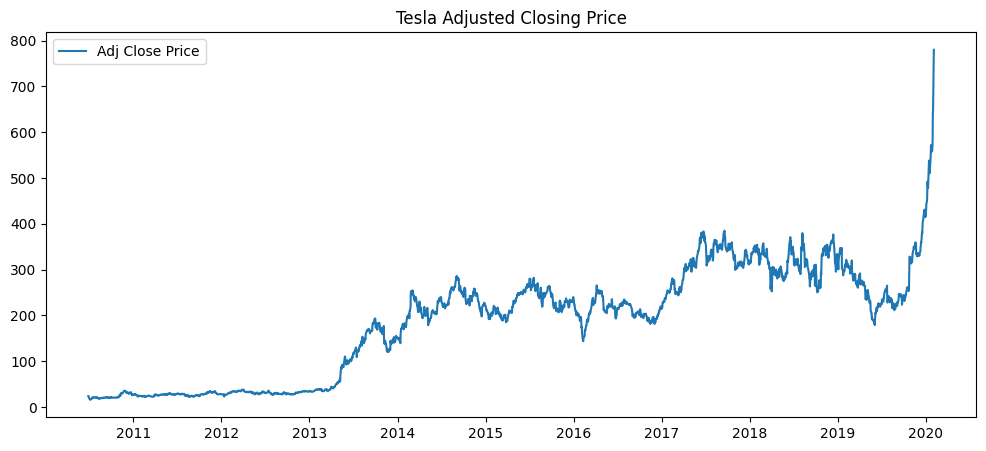


Data Prepared Successfully


E:\TeslaStockPrediction\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training RNN...
Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.0396 - val_loss: 0.0039
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0084 - val_loss: 0.0042
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0058 - val_loss: 0.0030
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0037 - val_loss: 0.0021
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0032 - val_loss: 0.0017
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0029 - val_loss: 0.0014
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0024 - val_loss: 0.0014
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0020 - val_loss: 8.8396e-04
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0017 - val_loss: 9.5858e-04
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0016 - val_loss: 8.5619e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0016 - val_loss: 7.3608e-04
Epoch 12/20
59/59 ━━━━━━━━━━━━

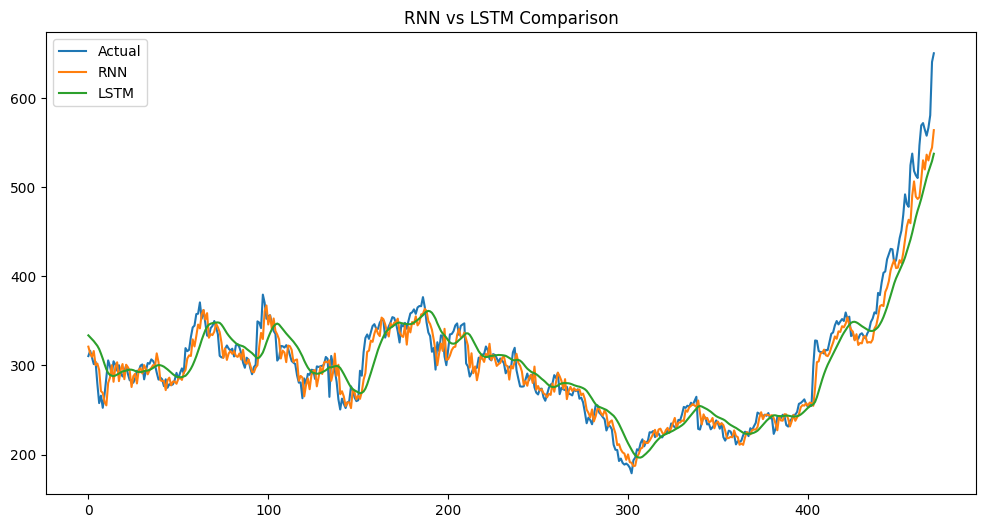


Model Performance:
RNN MSE: 267.7575770232826
LSTM MSE: 634.1543536858967

Future Predictions:

Next 1 day(s):
[563.2318]

Next 5 day(s):
[563.2318  572.4139  577.7998  580.46747 581.2436 ]

Next 10 day(s):
[563.2318  572.4139  577.7998  580.46747 581.2436  580.7277  579.34607
 577.3969  575.08466 572.5484 ]


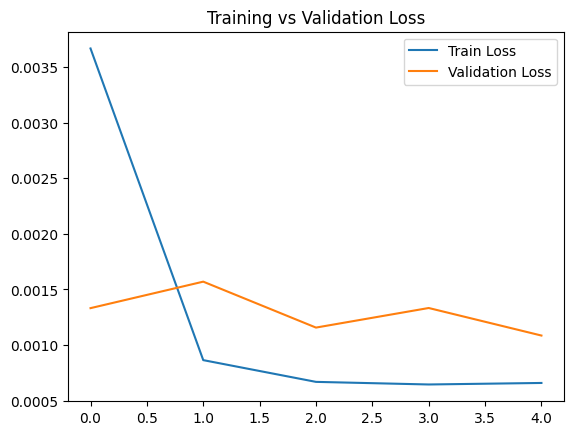


Models Saved Successfully!
Saved at: E:\TeslaStockPrediction\outputs\models\lstm_model.h5
File exists: True


In [1]:
# =========================================
# Tesla Stock Price Prediction 
# =========================================

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

print("Starting Project...")

# =========================================
# Load Dataset
# =========================================
df = pd.read_csv('../data/TSLA.csv')

print("\nDataset Loaded Successfully")
print(df.head())

# =========================================
# Data Cleaning
# =========================================
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)
df.fillna(method='ffill', inplace=True)

# =========================================
# Visualization
# =========================================
plt.figure(figsize=(12,5))
plt.plot(df['Adj Close'], label='Adj Close Price')
plt.title("Tesla Adjusted Closing Price")
plt.legend()
plt.show()

# =========================================
# Feature Selection (FIXED)
# =========================================
data = df[['Adj Close']]

# =========================================
# Scaling
# =========================================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# =========================================
# Create Time-Series Dataset
# =========================================
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# =========================================
# Reshape
# =========================================
X = X.reshape(X.shape[0], X.shape[1], 1)

# =========================================
# Train-Test Split
# =========================================
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("\nData Prepared Successfully")

# =========================================
# SimpleRNN Model
# =========================================
model_rnn = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(60,1)),
    Dropout(0.2),
    SimpleRNN(50),
    Dropout(0.2),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')

print("\nTraining RNN...")
early_stop = EarlyStopping(patience=5)

model_rnn.fit(X_train, y_train,
              epochs=20,
              batch_size=32,
              validation_data=(X_test, y_test),
              callbacks=[early_stop])

# =========================================
# LSTM Model
# =========================================
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60,1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

print("\nTraining LSTM...")

history_lstm = model_lstm.fit(X_train, y_train,
               epochs=20,
               batch_size=32,
               validation_data=(X_test, y_test),
               callbacks=[early_stop])

# =========================================
# Predictions
# =========================================
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)

pred_rnn = scaler.inverse_transform(pred_rnn)
pred_lstm = scaler.inverse_transform(pred_lstm)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# =========================================
# Visualization
# =========================================
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred_rnn, label='RNN')
plt.plot(pred_lstm, label='LSTM')
plt.title("RNN vs LSTM Comparison")
plt.legend()
plt.show()

# =========================================
# Evaluation
# =========================================
mse_rnn = mean_squared_error(y_test_actual, pred_rnn)
mse_lstm = mean_squared_error(y_test_actual, pred_lstm)

print("\nModel Performance:")
print("RNN MSE:", mse_rnn)
print("LSTM MSE:", mse_lstm)

# =========================================
# Future Prediction (1, 5, 10 days)
# =========================================
def predict_future(days):
    temp_input = list(scaled_data[-60:])
    predictions = []

    for i in range(days):
        x_input = np.array(temp_input[-60:])
        x_input = x_input.reshape(1,60,1)

        pred = model_lstm.predict(x_input, verbose=0)
        temp_input.append(pred[0])
        predictions.append(pred[0][0])

    return scaler.inverse_transform(np.array(predictions).reshape(-1,1))

print("\nFuture Predictions:")

for d in [1,5,10]:
    preds = predict_future(d)
    print(f"\nNext {d} day(s):")
    print(preds.flatten())

# =========================================
# Training Loss Graph
# =========================================
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# =========================================
# Save Models (FINAL FIXED)
# =========================================
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

model_dir = os.path.join(BASE_DIR, "outputs", "models")
os.makedirs(model_dir, exist_ok=True)

rnn_path = os.path.join(model_dir, "rnn_model.h5")
lstm_path = os.path.join(model_dir, "lstm_model.h5")

model_rnn.save(rnn_path)
model_lstm.save(lstm_path)

print("\nModels Saved Successfully!")
print("Saved at:", lstm_path)
print("File exists:", os.path.exists(lstm_path))

In [2]:
import os

# Create correct absolute path
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

model_dir = os.path.join(BASE_DIR, "outputs", "models")
model_path = os.path.join(model_dir, "lstm_model.h5")

# Create folder if not exists
os.makedirs(model_dir, exist_ok=True)

# Save model
model_lstm.save(model_path)

print("Model saved at:", model_path)

# Verify existence
print("File exists:", os.path.exists(model_path))

Model saved at: E:\TeslaStockPrediction\outputs\models\lstm_model.h5
File exists: True
